dataset chosen:MNIST (Handwritten digits)

In [ ]:
!pip uninstall -y torch torchvision torchaudio
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu


Found existing installation: torch 2.9.1+cpu
Uninstalling torch-2.9.1+cpu:
  Successfully uninstalled torch-2.9.1+cpu
Found existing installation: torchvision 0.24.1+cpu
Uninstalling torchvision-0.24.1+cpu:
  Successfully uninstalled torchvision-0.24.1+cpu
Found existing installation: torchaudio 2.9.1+cpu
Uninstalling torchaudio-2.9.1+cpu:
  Successfully uninstalled torchaudio-2.9.1+cpu
Looking in indexes: https://download.pytorch.org/whl/cpu
  Using cached https://download.pytorch.org/whl/cpu/torch-2.9.1%2Bcpu-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (29 kB)
  Using cached https://download.pytorch.org/whl/cpu/torchvision-0.24.1%2Bcpu-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (5.9 kB)
  Using cached https://download.pytorch.org/whl/cpu/torchaudio-2.9.1%2Bcpu-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (6.9 kB)
Using cached https://download.pytorch.org/whl/cpu/torch-2.9.1%2Bcpu-cp312-cp312-manylinux_2_28_x86_64.whl (184.4 MB)
Using cached https://download.pytorch.org/whl/c

In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


Image: 28 × 28 matrix
Label: single number (0–9)
train-images-idx3-ubyte.gz → training images

train-labels-idx1-ubyte.gz → training labels

t10k-images-idx3-ubyte.gz → test images

t10k-labels-idx1-ubyte.gz → test labels

**1. Data Loading & Preprocessing**

In [2]:
# 2. Define Transformations (Normalization)
# MNIST images are grayscale with pixel values in [0, 255]
# Normalize them to range [-1, 1]
#ToTensor()Converts the image from PIL format to PyTorch tensor and scales pixel values from [0, 255] to [0, 1].

transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


In [3]:
#load dataset
# root='./data' → Location where dataset is stored.

# train=True → Loads training data (60,000 images).

# train=False → Loads testing data (10,000 images).

# transform=transform → Applies preprocessing to every image.

# download=True → Downloads dataset if not already present.

train_dataset=datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    transform=transform,
    download=True
)


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.89MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 155kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.49MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.45MB/s]


In [4]:
#instead of training on all images at once we will process data in small batches
batch_size = 64


In [5]:
# Loads training data in batches of 64.

# shuffle=True ensures the model does not learn data order patterns.
train_loader=DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)

In [6]:
# Testing data is not shuffled to maintain consistency during evaluation.
#Testing data ko shuffle nahi karte kyunki usse learning nahi hoti, aur fixed order se model ki performance ko fair aur consistent tareeke se measure kiya ja sakta hai.

test_loader=DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [7]:
data_iter=iter(train_loader) #makes datloader iterator
images,labels=next(data_iter) #ek batch ka data nikalta

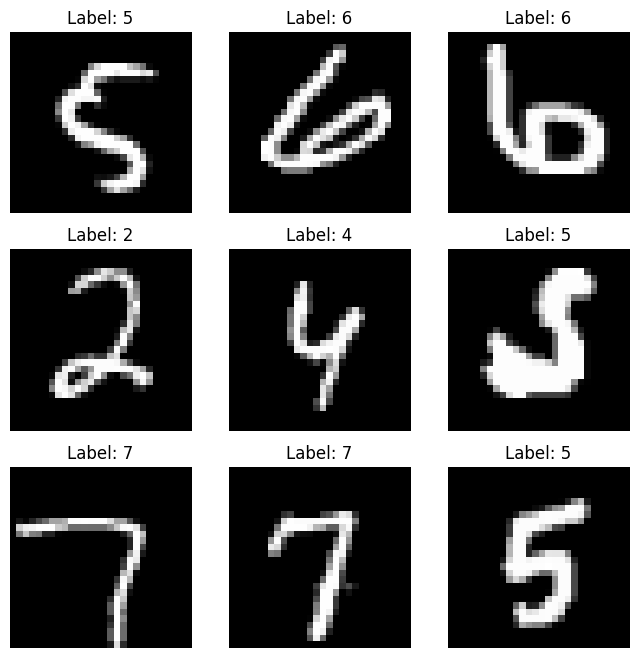

In [12]:
plt.figure(figsize=(8, 8))
for i in range(9):
    #subplot(rows, columns, position)&pos starts from 1 so i+1

    plt.subplot(3, 3,i+1) #3x3 grid
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(f"Label: {labels[i].item()}")
    plt.axis('off')

plt.show()


**2. ANN MODEL IMPLEMENTATION**

In [13]:
import torch.nn as nn

## ANN Model – Logical Explanation

### Why Flattening is Required

MNIST images have the shape:

    [1, 28, 28]

- `1` → grayscale channel  
- `28 × 28` → pixel dimensions  

A **fully connected Artificial Neural Network (ANN)** cannot process 2D images directly.  
It only accepts **1D vectors** as input.

---

### Flattening Operation

```python
x = x.view(x.size(0), -1)
28 × 28 image → 784 length vector
Hence, the input layer must have 784 neurons

In [20]:
import torch.nn as nn

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        # layers
        self.la1 = nn.Linear(28*28, 256)
        self.la2 = nn.Linear(256, 128)
        self.la3 = nn.Linear(128, 64)
        self.la4 = nn.Linear(64, 10) #10 neurons digits 0-9 for output

        # activation function
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(x.size(0), -1)

        # forward propagation
        x = self.relu(self.la1(x))
        x = self.relu(self.la2(x))
        x = self.relu(self.la3(x))
        x = self.la4(x)

#Output layer me ReLU nahi lagate
#(kyunki classification loss function khud handle karta hai)

        return x
model=ANN()
print(model)


ANN(
  (la1): Linear(in_features=784, out_features=256, bias=True)
  (la2): Linear(in_features=256, out_features=128, bias=True)
  (la3): Linear(in_features=128, out_features=64, bias=True)
  (la4): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
)


**3. Training Pipeline**

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim


In [21]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 10
train_losses = []
train_accuracies = []


In [23]:
# Loss function: prediction aur actual label ke beech error calculate karta hai
criterion = nn.CrossEntropyLoss()

# Optimizer: model ke weights update karta hai taaki loss kam ho
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Model ko 10 baar poore training data se train karenge
epochs = 10

# Har epoch ka loss aur accuracy store karne ke liye lists
train_losses = []
train_accuracies = []

# Epoch loop (training rounds)
for epoch in range(epochs):

    running_loss = 0.0     # Poore epoch ka total loss
    correct = 0            # Sahi predictions count
    total = 0              # Total images count

    # Training data ko batch-by-batch process karna
    for images, labels in train_loader:

        optimizer.zero_grad()       # Pichle batch ke gradients clear

        outputs = model(images)     # Forward pass: model prediction

        loss = criterion(outputs, labels)  # Loss calculate

        loss.backward()             # Backpropagation: gradients calculate
        optimizer.step()            # Weights update

        running_loss += loss.item() # Batch loss ko total loss me add

        # Prediction: highest score wala class select
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)     # Total images count
        correct += (predicted == labels).sum().item()  # Correct predictions

    # Poore epoch ka average loss
    epoch_loss = running_loss / len(train_loader)

    # Poore epoch ki accuracy
    epoch_acc = 100 * correct / total


    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)


    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Loss: {epoch_loss:.4f}, "
          f"Accuracy: {epoch_acc:.2f}%")


Epoch [1/10] Loss: 0.0775, Accuracy: 97.56%
Epoch [2/10] Loss: 0.0655, Accuracy: 97.90%
Epoch [3/10] Loss: 0.0574, Accuracy: 98.17%
Epoch [4/10] Loss: 0.0515, Accuracy: 98.32%
Epoch [5/10] Loss: 0.0464, Accuracy: 98.47%
Epoch [6/10] Loss: 0.0425, Accuracy: 98.61%
Epoch [7/10] Loss: 0.0403, Accuracy: 98.63%
Epoch [8/10] Loss: 0.0369, Accuracy: 98.73%
Epoch [9/10] Loss: 0.0361, Accuracy: 98.84%
Epoch [10/10] Loss: 0.0311, Accuracy: 98.96%


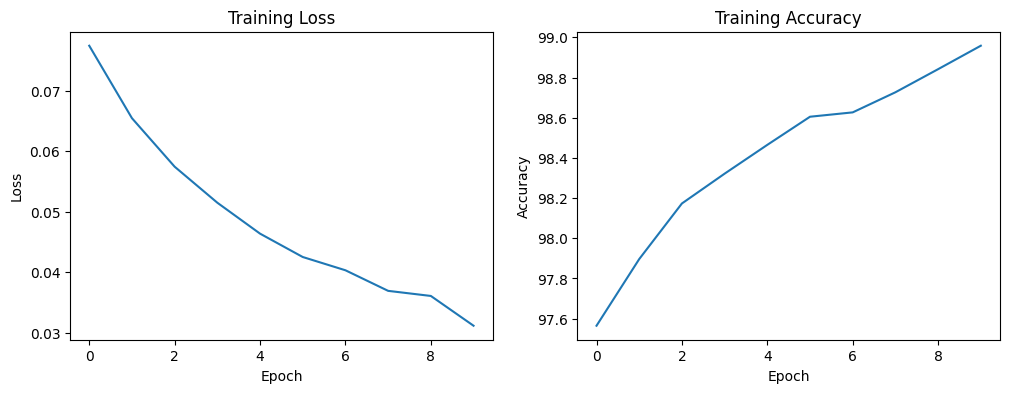

In [24]:
# Plot Training Loss & Accuracy
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1,2,2)
plt.plot(train_accuracies)
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.show()


In [25]:
# 5. Model Evaluation
model.eval()
correct = 0
total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

test_accuracy = 100 * correct / total
print(f'Test Accuracy: {test_accuracy:.2f}%')


Test Accuracy: 97.69%


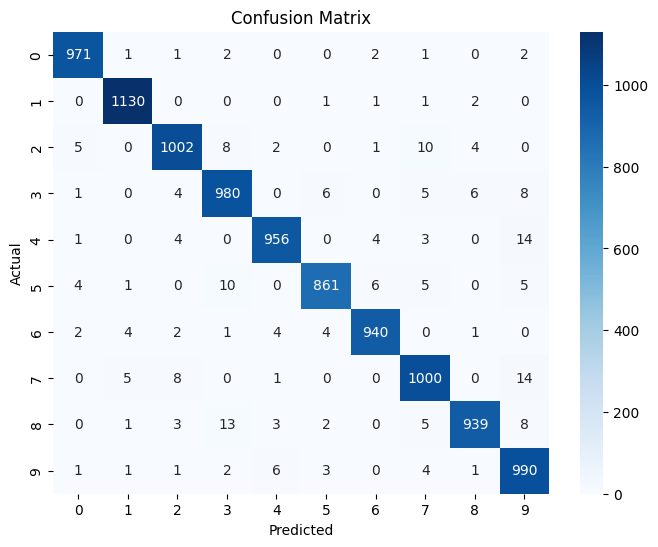

In [28]:
# 6. Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


**Report**  
In this assignment ANN was implemented using PyTorch to classify handwritten digits from MNIST dataset.  
The model architecture consists of an input layer, three hidden layers, and an output layer. Since MNIST images are of size 28×28, they are first flattened into a 784-dimensional input vector. The hidden layers contain 256, 128, and 64 neurons respectively, each followed by a ReLU activation function to introduce non-linearity and enable the network to learn complex patterns. The output layer has 10 neurons corresponding to the digit classes from 0 to 9.   
 For training, CrossEntropyLoss was used as the loss function, The Adam optimizer was chosen with a learning rate of 0.001  The model was trained for 10 epochs with a batch size of 64.  
**Test Accuracy: 97.69%**
